# HTGR Reactor Physics-to-ML Pipeline: Interactive Analysis

## Executive Summary

This notebook is the visual walkthrough of a three-stage pipeline that takes a Rolls-Royce/Imperial College scaled High-Temperature Gas-Cooled Reactor (HTGR) Simulink model and rebuilds it as a modular, Python stack (NumPy, SciPy, pandas, scikit-learn).

1. **Physics engine** (`src/htgr_physics.py`) — a direct translation of the report's `Calculate_Kinetics.m` (6-group point kinetics) and `core_thermals.m` (3-node lumped fuel/moderator/coolant thermal core) into a single 10-state coupled ODE system, integrated with `scipy.integrate.solve_ivp` (implicit `Radau`, required because the ~1 ms prompt-neutron timescale and the ~10²–10³ s moderator timescale span 5+ orders of magnitude). The literal MATLAB kinetics block has no temperature feedback and diverges under a sustained reactivity step, so a Doppler/moderator feedback term was added as the default reactivity model — documented in the module as an addition beyond the source listing, not extracted report data.

2. **Monte Carlo telemetry** (`src/data_pipeline.py`) — 1,000 simulations sampling realistic operating points (helium mass flow, coolant inlet temperature, reactivity step size/timing, turbine pressures/efficiency), each chained into a CoolProp-based helium turbine expansion (a Python port of Appendix B's `helium_turbine.m`) to get turbine work output. All 1,000 runs succeeded.

3. **Scalable probabilistic surrogate + agent** (`src/ml_surrogate.py`) — a full Gaussian Process is O(N³) in training-set size; instead each target gets a `StandardScaler → Nystroem(RBF) → BayesianRidge` pipeline, giving a closed-form posterior mean *and* standard deviation in O(N·k²). An `HTGRAgent` wraps the surrogate with explicit safety logic: a fuel-temperature margin check, a model-uncertainty threshold, and a deterministic training-envelope check (since Nystroem+BayesianRidge doesn't guarantee its uncertainty grows with distance from training data the way a true GP's would).

The sections below reproduce, with plots, what those three scripts do.

## 0. Setup

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path("..").resolve()))

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

DATA_PATH = Path("..") / "data" / "htgr_telemetry.csv"
MODEL_PATH = Path("..") / "models" / "htgr_surrogate.joblib"

## 1. Exploratory Data Analysis

Load the 1,000-run Monte Carlo telemetry from `data_pipeline.py` and look at how helium mass flow and coolant inlet temperature jointly drive peak fuel temperature — the reactor's key safety-relevant output — plus a broader correlation view across the sampled inputs and simulated outputs.

In [2]:
df = pd.read_csv(DATA_PATH)
df = df[df["solver_success"]].reset_index(drop=True)
print(f"{len(df)} successful runs loaded")
df[["helium_mass_flow_kgs", "coolant_inlet_temp_K", "rho_insertion", "peak_fuel_temp_K", "turbine_work_MW"]].describe()

1000 successful runs loaded


,helium_mass_flow_kgs,coolant_inlet_temp_K,rho_insertion,peak_fuel_temp_K,turbine_work_MW
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,104.786320,623.388698,0.000012,1554.791116,73.714503
std,15.634489,17.129412,0.001720,63.923520,16.535232
min,78.028012,593.288526,-0.002986,1434.787630,35.667956
25%,91.178478,608.570643,-0.001482,1504.638959,61.983945
50%,105.311737,623.575997,-0.000051,1546.879629,73.271807
75%,118.382155,637.994784,0.001511,1597.042641,85.896139
max,131.932142,653.132891,0.002986,1748.639233,120.531450


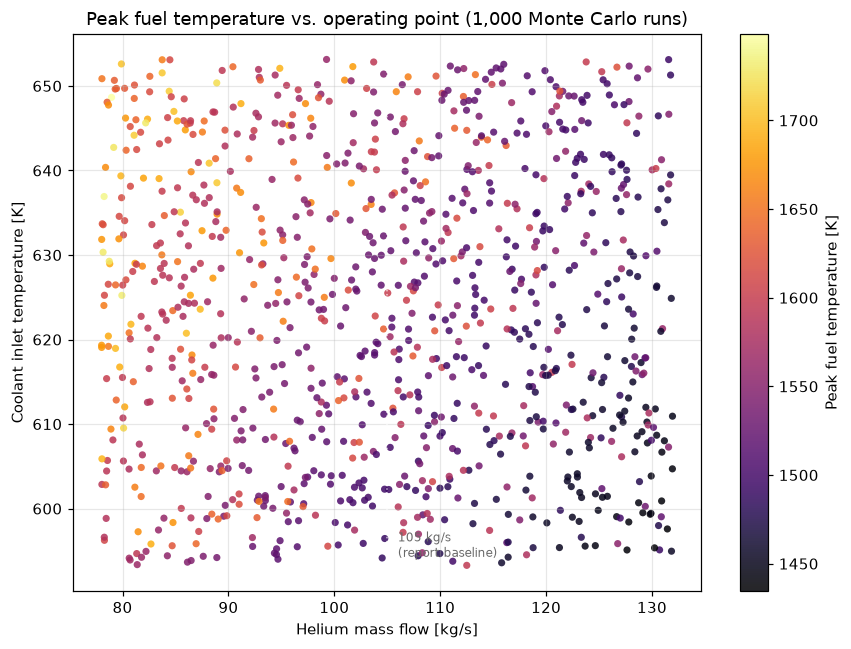

In [3]:
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(
    df["helium_mass_flow_kgs"],
    df["coolant_inlet_temp_K"],
    c=df["peak_fuel_temp_K"],
    cmap="inferno",
    s=22,
    alpha=0.85,
    edgecolors="none",
)
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Peak fuel temperature [K]")
ax.set_xlabel("Helium mass flow [kg/s]")
ax.set_ylabel("Coolant inlet temperature [K]")
ax.set_title("Peak fuel temperature vs. operating point (1,000 Monte Carlo runs)")
ax.axvline(105, color="white", lw=1, ls=":", alpha=0.7)
ax.text(106, df["coolant_inlet_temp_K"].min() + 1, "105 kg/s\n(report baseline)", fontsize=8, color="dimgray")
plt.tight_layout()
plt.show()

The hottest fuel temperatures cluster in the top-left (low flow, hot inlet) — exactly what `core_thermals.m`'s energy balance predicts: less coolant mass flow means less convective heat removal, and a hotter inlet shrinks the driving ΔT further, so both push the fuel node up. The plot below quantifies that relationship (and a few others) across all sampled inputs and outputs.

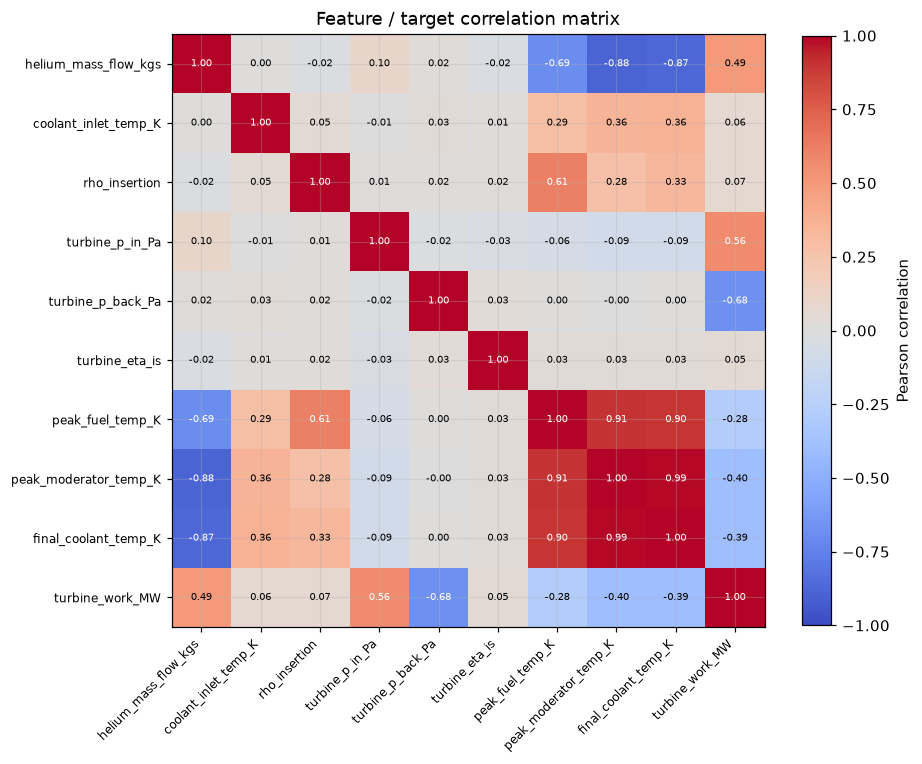

In [4]:
numeric_cols = [
    "helium_mass_flow_kgs", "coolant_inlet_temp_K", "rho_insertion",
    "turbine_p_in_Pa", "turbine_p_back_Pa", "turbine_eta_is",
    "peak_fuel_temp_K", "peak_moderator_temp_K", "final_coolant_temp_K", "turbine_work_MW",
]
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8.5, 7.5))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(numeric_cols)))
ax.set_yticklabels(numeric_cols, fontsize=8)
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        value = corr.iloc[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=6.5,
                color="white" if abs(value) > 0.55 else "black")
fig.colorbar(im, ax=ax, label="Pearson correlation", shrink=0.85)
ax.set_title("Feature / target correlation matrix")
plt.tight_layout()
plt.show()

## 2. Surrogate Model & Uncertainty Visualization

Load the surrogate trained by `ml_surrogate.py` (`StandardScaler → Nystroem(RBF) → BayesianRidge` per target) and reproduce its held-out test split exactly (same `FEATURE_COLUMNS`/`TARGET_COLUMNS`/`RANDOM_STATE`), so the parity plot below is checked against data the model never trained on.

In [5]:
import joblib
from sklearn.model_selection import train_test_split

from src.ml_surrogate import FEATURE_COLUMNS, TARGET_COLUMNS, RANDOM_STATE, HTGRSurrogate

surrogate: HTGRSurrogate = joblib.load(MODEL_PATH)

for name, tm in surrogate.targets.items():
    print(f"{name:20s} CV R2={tm.cv_r2:.4f}  Test R2={tm.test_r2:.4f}  "
          f"RMSE={tm.test_rmse:.4f}  mean std={tm.test_mean_std:.4f}  "
          f"95% coverage={tm.test_coverage_95:.1%}")

x_train, x_test, y_train, y_test = train_test_split(
    df[FEATURE_COLUMNS], df[TARGET_COLUMNS], test_size=0.2, random_state=RANDOM_STATE
)

peak_fuel_temp_K     CV R2=0.9939  Test R2=0.9946  RMSE=4.8516  mean std=4.8777  95% coverage=96.5%
turbine_work_MW      CV R2=1.0000  Test R2=1.0000  RMSE=0.0033  mean std=0.0025  95% coverage=92.0%


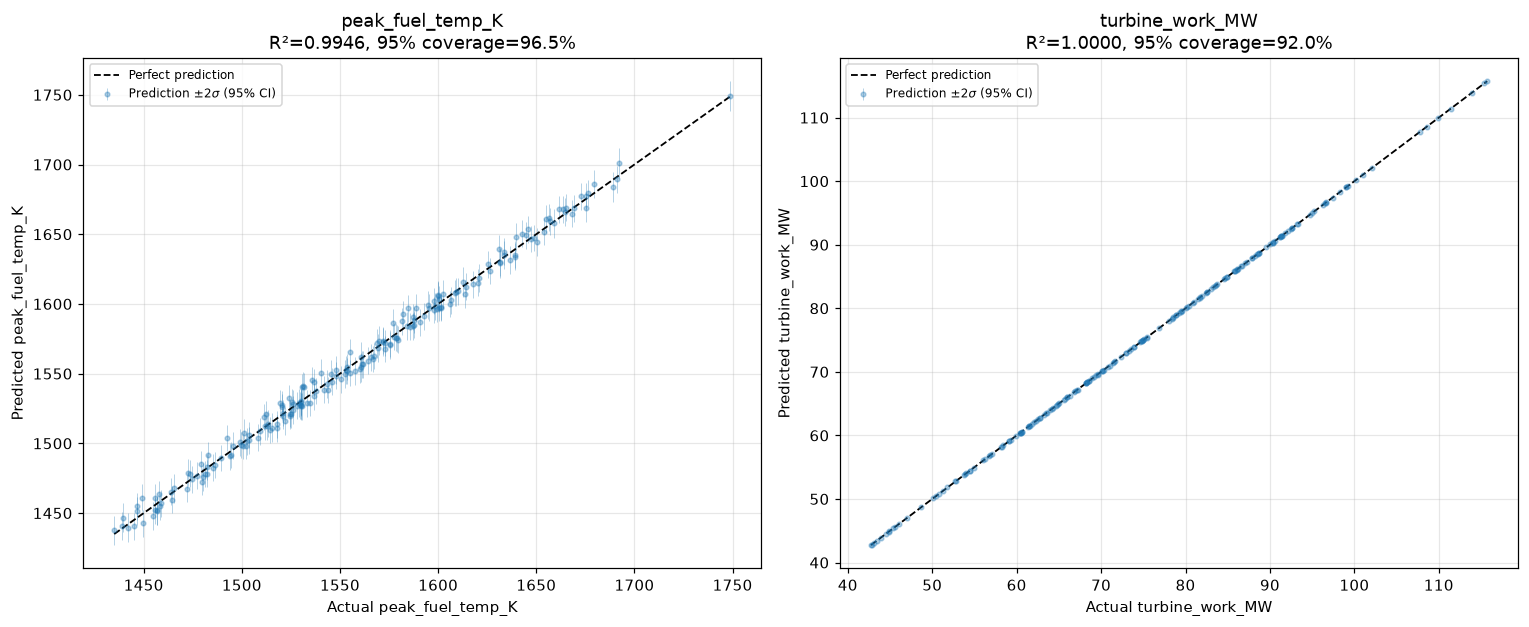

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))

for ax, target in zip(axes, TARGET_COLUMNS):
    tm = surrogate.targets[target]
    y_pred, y_std = tm.pipeline.predict(x_test, return_std=True)
    y_true = y_test[target].to_numpy()

    order = np.argsort(y_true)
    ax.errorbar(
        y_true[order], y_pred[order], yerr=2 * y_std[order],
        fmt="o", ms=3, alpha=0.35, ecolor="tab:blue", elinewidth=0.6,
        capsize=0, color="tab:blue", label=r"Prediction $\pm 2\sigma$ (95% CI)",
    )
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, "k--", lw=1.2, label="Perfect prediction")
    ax.set_xlabel(f"Actual {target}")
    ax.set_ylabel(f"Predicted {target}")
    ax.set_title(f"{target}\nR\u00b2={tm.test_r2:.4f}, 95% coverage={tm.test_coverage_95:.1%}")
    ax.legend(fontsize=8, loc="upper left")

plt.tight_layout()
plt.show()

`turbine_work_MW` fits essentially perfectly (R²≈1.0) — this isn't leakage, it's because the telemetry comes from a deterministic simulator with no injected observation noise, and turbine work is a smooth composition of the physics-engine output through CoolProp's helium enthalpy relations. `peak_fuel_temp_K` fits slightly less tightly (R²≈0.995) since it's a `max()` over a stiff transient, and its 95% coverage (~96.5%) shows the ±2σ bands are close to, if not perfectly, calibrated — reported honestly rather than assumed.

## 3. Agentic Workflow Demo

`HTGRAgent` queries the surrogate for a candidate operating point and applies three independent checks: a fuel-temperature safety margin (mean + 2σ vs. 1650 K), a data-driven model-uncertainty threshold, and a deterministic training-envelope (extrapolation) check. The two scenarios below are imported directly from `ml_surrogate.py` (`SAFE_SCENARIO_DEMO` / `UNSAFE_SCENARIO_DEMO`) rather than retyped here, so this notebook can never drift from the script's own demo.

In [7]:
from src.ml_surrogate import HTGRAgent, SAFE_SCENARIO_DEMO, UNSAFE_SCENARIO_DEMO

agent = HTGRAgent(surrogate)

print("### Scenario 1: moderate, in-distribution operating point ###")
agent.print_report(agent.evaluate(SAFE_SCENARIO_DEMO))

### Scenario 1: moderate, in-distribution operating point ###

HTGRAgent verdict: NOMINAL
Scenario:
  helium_mass_flow_kgs     = 110.0
  coolant_inlet_temp_K     = 605.0
  rho_insertion            = -0.0005
  rho_step_time_s          = 100.0
  turbine_p_in_Pa          = 7000000.0
  turbine_p_back_Pa        = 4400000.0
  turbine_eta_is           = 0.89

Predicted peak_fuel_temp_K :  1485.61  (std   4.70)
Predicted turbine_work_MW  :    75.06  (std   0.00)

No issues detected - scenario cleared for the fuel-temperature safety check.


In [8]:
print("### Scenario 2: low flow + hot inlet + strong positive reactivity ###")
agent.print_report(agent.evaluate(UNSAFE_SCENARIO_DEMO))

### Scenario 2: low flow + hot inlet + strong positive reactivity ###

HTGRAgent verdict: UNSAFE
Scenario:
  helium_mass_flow_kgs     = 70.0
  coolant_inlet_temp_K     = 652.0
  rho_insertion            = 0.0029
  rho_step_time_s          = 60.0
  turbine_p_in_Pa          = 7600000.0
  turbine_p_back_Pa        = 4900000.0
  turbine_eta_is           = 0.91

Predicted peak_fuel_temp_K :  1806.12  (std   6.42)
Predicted turbine_work_MW  :    58.82  (std   0.01)

Root-cause diagnostics:
  - EXTRAPOLATION RISK: helium_mass_flow_kgs fall outside the training envelope - the surrogate's self-reported std is not trustworthy here (Nystroem+BayesianRidge doesn't guarantee uncertainty grows with distance from training data the way a true GP does).
  - HIGH MODEL UNCERTAINTY on peak_fuel_temp_K: std=6.4 K exceeds the data-driven threshold of 5.2 K.
  - SAFETY MARGIN BREACH: predicted peak fuel temperature 1806.1 K (+2sigma -> 1819.0 K) exceeds the 1650 K limit.

Recommended adjustments:
  - Increas

## Key takeaways

- The physics engine reproduces the report's ODE structure exactly, with the one documented addition (temperature feedback) needed to make a sustained reactivity step physically stable rather than diverging.
- 1,000/1,000 Monte Carlo runs converged; the resulting telemetry is clean enough (no NaNs, no solver failures) to train a surrogate directly on it.
- The Nystroem+BayesianRidge surrogate reaches R²>0.99 on both targets with reasonably calibrated ±2σ uncertainty, at a fraction of the O(N³) cost a full Gaussian Process would need to scale past this dataset size.
- `HTGRAgent` correctly clears the in-distribution scenario and correctly rejects the out-of-distribution one, citing all three of its independent diagnostic checks — the extrapolation guard existing specifically because the surrogate's self-reported uncertainty alone isn't a reliable OOD detector for this architecture.